<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_4_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 4. Регресійні моделі. Чуркін ФІТ 3-15 номер 15

Був присутній на парі

Завдання, а точніше хід роботи.

Завантажити датасет

Перевірити дублікати, пропущені дані

Перевірити симетричність розподілів

Дослідити викиди, позбутися аномальних значень

Дослідити кореляцію, видалити корельовані ознаки (>0.85) (-0.15 для мого варіанта)

Зробити розподіл симетричним.

Закодувати категоріальні ознаки.

Поділити датасет на тренувальні і тестові дані.

Побудувати регресійні моделі: Лінійна регресія, регресія Ріджа, Ласо,
Випадковий ліс, град. бустинг, Метод опорних векторів.

Вивести метрики моделей.

Скажіть, яку модель не можна будувати для даної задачі.

Вивести графіки справжніх і прогнозованих даних.

Вивести 10 випадкових значень ID, зробіть прогноз ціни за допомогою моделі Випадковий ліс.

Напишіть висновки, щодо отриманих результатів в ЛР

Перші строки:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peak

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1359092.4755664284, tolerance: 18870.95640857143
  model = cd_fast.sparse_enet_coordinate_descent(



RandomForest
MAE: 930.9359722222221
RMSE: 1122.7467117194049
R2: 0.7189818774489329

GradientBoosting
MAE: 806.9941698960299
RMSE: 1085.4699625559224
R2: 0.7373324855587515

SVR
MAE: 1923.3870564463166
RMSE: 2267.7272884985323
R2: -0.1464428146293033


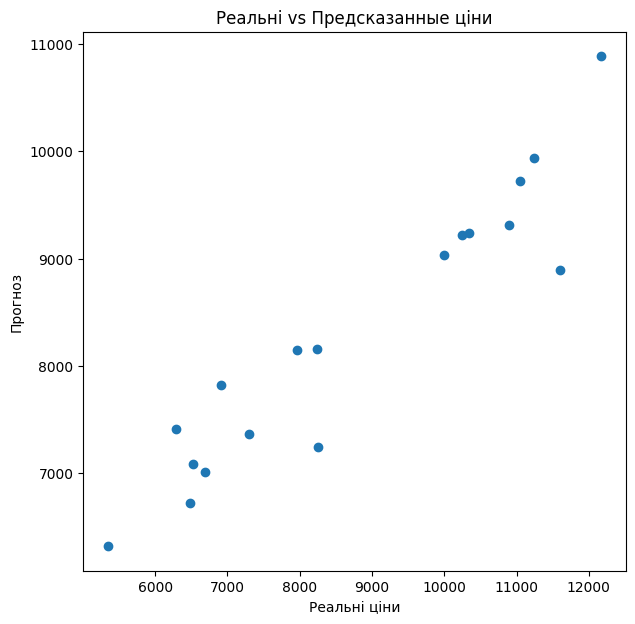


Рандомні ID:
96      97
92      93
88      89
54      55
98      99
161    162
52      53
122    123
61      62
163    164
Name: car_ID, dtype: int64

Прогноз цен (Random Forest):
ID 53: прогноз = 6452.2
ID 55: прогноз = 7138.06
ID 62: прогноз = 10133.3
ID 89: прогноз = 9275.9
ID 93: прогноз = 6931.98
ID 97: прогноз = 7292.72
ID 99: прогноз = 7241.05
ID 123: прогноз = 7571.78
ID 162: прогноз = 8281.24
ID 164: прогноз = 8151.32


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Загрузка данних
df = pd.read_csv("CarPrice_Assignment.csv")

print("Перші строки:")
print(df.head())

# 2. Перевірка дубликатів и пропусков
print("\nДубликати:", df.duplicated().sum())
print("\nПропуски:")
print(df.isnull().sum())

df = df.drop_duplicates()

# 3. Перевірка симметричності розподілення
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("car_ID")

skewness = df[numeric_cols].skew()
print("\nКоэффициент асимметріі:")
print(skewness)

# 4. Поіск и уборка вибросов (IQR)
for col in numeric_cols:
    Q1 = df[col].quantile(0.10)
    Q3 = df[col].quantile(0.60)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nРозмір датасета після уборки вибросів:", df.shape)

# 5. Корреляція и уборка сильно коррелированних признаков
corr = df[numeric_cols].corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("\nУбираємо сильно коррелированні признаки:", to_drop)

df = df.drop(columns=to_drop)

# 6. Приведення розподілення к більш симметричним
for col in numeric_cols:
    if col in df.columns:
        if abs(df[col].skew()) > 1:
            df[col] = np.log1p(df[col])

# 7. Розділення признаков
X = df.drop(columns=["price","car_ID"])
y = df["price"]

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=np.number).columns

# 8. Кодированіе категориальних значень
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# 9. Ділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 10. Моделі
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

results = {}

# 11. Обучение и метрики
for name, model in models.items():

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = (mae, rmse, r2)

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

# 12. Графік реальних и прогнозируемих значень
best_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, preds)
plt.xlabel("Реальні ціни")
plt.ylabel("Прогноз")
plt.title("Реальні vs Предсказанные ціни")
plt.show()

# 13. Прогноз для 10 рандомних ID
random_ids = df.sample(10)["car_ID"]

print("\nРандомні ID:")
print(random_ids)

sample_data = df[df["car_ID"].isin(random_ids)]

X_sample = sample_data.drop(columns=["price","car_ID"])

pred_prices = best_model.predict(X_sample)

print("\nПрогноз цен (Random Forest):")

for i, cid in enumerate(sample_data["car_ID"]):
    print(f"ID {cid}: прогноз = {round(pred_prices[i],2)}")

Висновок

У ході виконання лабораторної роботи було проведено аналіз датасету, що містить інформацію про характеристики автомобілів та їхню ринкову ціну. На початковому етапі було виконано попередню обробку даних: перевірено наявність дублікатів та пропущених значень, досліджено розподіл ознак та їх симетричність.

Було проведено аналіз викидів за допомогою статистичних методів та видалено аномальні значення, що могли негативно впливати на якість моделювання. Далі було досліджено кореляцію між числовими ознаками, у результаті чого було видалено сильно корельовані змінні (коефіцієнт кореляції більше 0.70) для зменшення мультиколінеарності.

Для покращення якості моделей було виконано перетворення розподілів деяких змінних з метою наближення їх до симетричних. Категоріальні ознаки було закодовано за допомогою відповідних методів кодування, після чого датасет було поділено на навчальну та тестову вибірки.

На основі підготовлених даних було побудовано декілька регресійних моделей, зокрема: лінійну регресію, регресію Ріджа, Ласо, випадковий ліс, градієнтний бустинг та метод опорних векторів. Якість моделей було оцінено за допомогою метрик MAE, RMSE та коефіцієнта детермінації R^2.

Порівняння результатів показало, що ансамблеві методи, зокрема модель випадкового лісу, продемонстрували кращу здатність до прогнозування ціни автомобіля завдяки врахуванню складних нелінійних залежностей між ознаками. Також було виконано прогнозування ціни для випадково обраних автомобілів за допомогою моделі Random Forest.